# Student Performance Indicator

# Life cycle of ML Project:

1.  Understanding the Problem Statement
2.  Data Collection
3.  Data Checks to perform
4.  Exploratory data analysis (**EDA**)
5.  Data Pre-Processing
6.  Model Training
7.  Choose best model

## 1) Problem Statement

- To understand the influence of the parents background, test preparation etc on students performance

## 2) Data Collection

- Dataset Source - https://www.kaggle.com/datasets/spscientist/students-performance-in-exams?resource=download
- The data contains 8 rows and 1000 columns.

### 2.1) Import Data and Required Packeages

Importing Pandas, Numpy, Matplotlib, Seaborn and Warnings Library.

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [5]:
df = pd.read_csv('data/StudentsPerformance.csv')

In [6]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


## 3) Data Checks To Perform

- Check Missing values
- Check Duplicates
- Check Data Type
- Check the number of unique values of each column
- Check Statistics of data set
- Check various categories present in the different categorical column

### 3.1 Check Missing values

In [7]:
df.isna().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

### 3.2 Check Duplicates

In [8]:
df.duplicated().sum()

np.int64(0)

### 3.3 Check Data Types

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


### 3.4 Check the number of unique values of each column

In [10]:
df.nunique()

gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     81
reading score                  72
writing score                  77
dtype: int64

### 3.5 Check Statistics of data set

In [11]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


### 3.6 Check various categories present in the different categorical column

In [14]:
for col in df.select_dtypes(include='object').columns:
    print(f"- {col} =====>   {df[col].unique()}")

- gender =====>   ['female' 'male']
- race/ethnicity =====>   ['group B' 'group C' 'group A' 'group D' 'group E']
- parental level of education =====>   ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
- lunch =====>   ['standard' 'free/reduced']
- test preparation course =====>   ['none' 'completed']


### 3.7 Numerical & Categorical features 

In [15]:
numerical_columns = df.select_dtypes(include=['int64','float64']).columns
print("Numerical Columns:", list(numerical_columns))

Numerical Columns: ['math score', 'reading score', 'writing score']


In [17]:
numerical_columns = df.select_dtypes(include='object').columns
print("Categorical Columns:", list(numerical_columns))

Categorical Columns: ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


## Feature Engineering

### 3.8 Adding columns for "Total Score" and "Average"

In [18]:
df['total score'] = df['math score'] + df['reading score'] + df['writing score']
df['average'] = df['total score']/3
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


### 3.9

In [20]:
reading_full = df[df['reading score'] == 100]['average'].count()
writing_full = df[df['writing score'] == 100]['average'].count()
math_full = df[df['math score'] == 100]['average'].count()

print("Students with full marks in Reading:", reading_full)
print("Students with full marks in Writing:", writing_full)
print("Students with full marks in Math:", math_full)


Students with full marks in Reading: 17
Students with full marks in Writing: 14
Students with full marks in Math: 7


### 4.0

In [21]:
reading_20 = df[df['reading score'] <= 20]['average'].count()
writing_20 = df[df['writing score'] <= 20]['average'].count()
math_20 = df[df['math score'] <= 20]['average'].count()

print("Students with reading score ≤ 20:", reading_20)
print("Students with writing score ≤ 20:", writing_20)
print("Students with math score ≤ 20:", math_20)


Students with reading score ≤ 20: 1
Students with writing score ≤ 20: 3
Students with math score ≤ 20: 4


### Insights:
- Math typically has more students in the ≤20 range compared to reading and writing.
This means math is the weakest subject overall, requiring additional intervention.
- Reading and writing have relatively fewer students scoring ≤20, indicating
language skills are stronger than math.

### 4.1 Visualize avg. socre distribution

- Histogram
- Kernel Distribution Function (KDE)

#### 4.1.1 Histogram & KDE

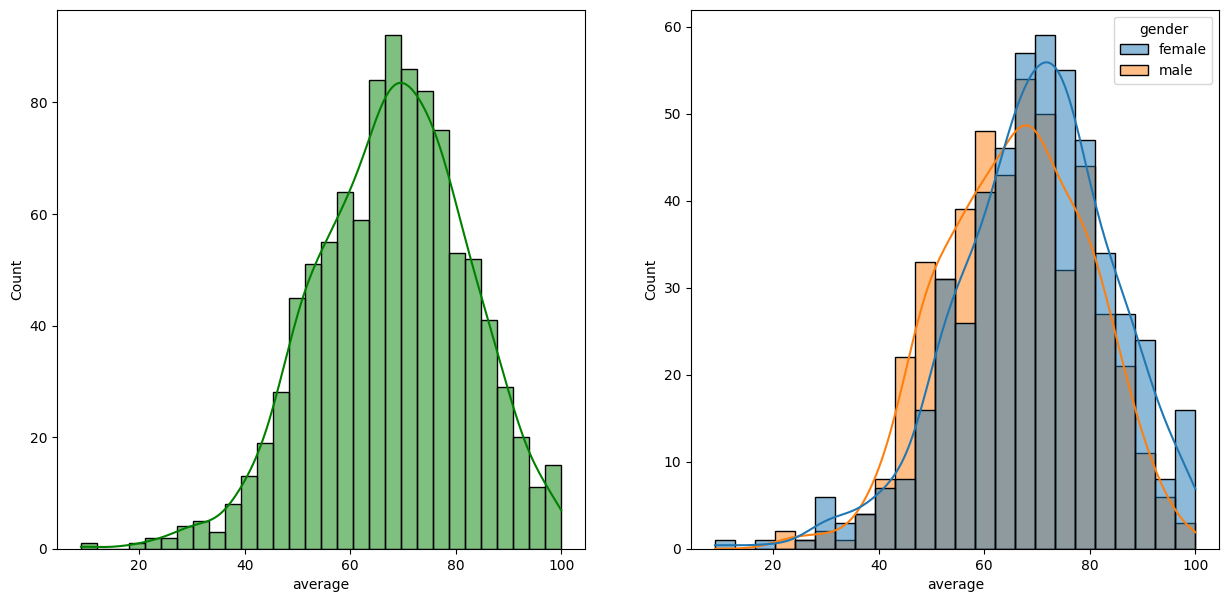

In [22]:
fig, axs = plt.subplots(1, 2, figsize = (15, 7))
plt.subplot(121)
sns.histplot(data= df, x= 'average', bins=30, kde=True, color='g')
plt.subplot(122)
sns.histplot(data= df, x= 'average', kde=True, hue='gender')
plt.show()

### Insights:

- Female students tend to perform well than male students.

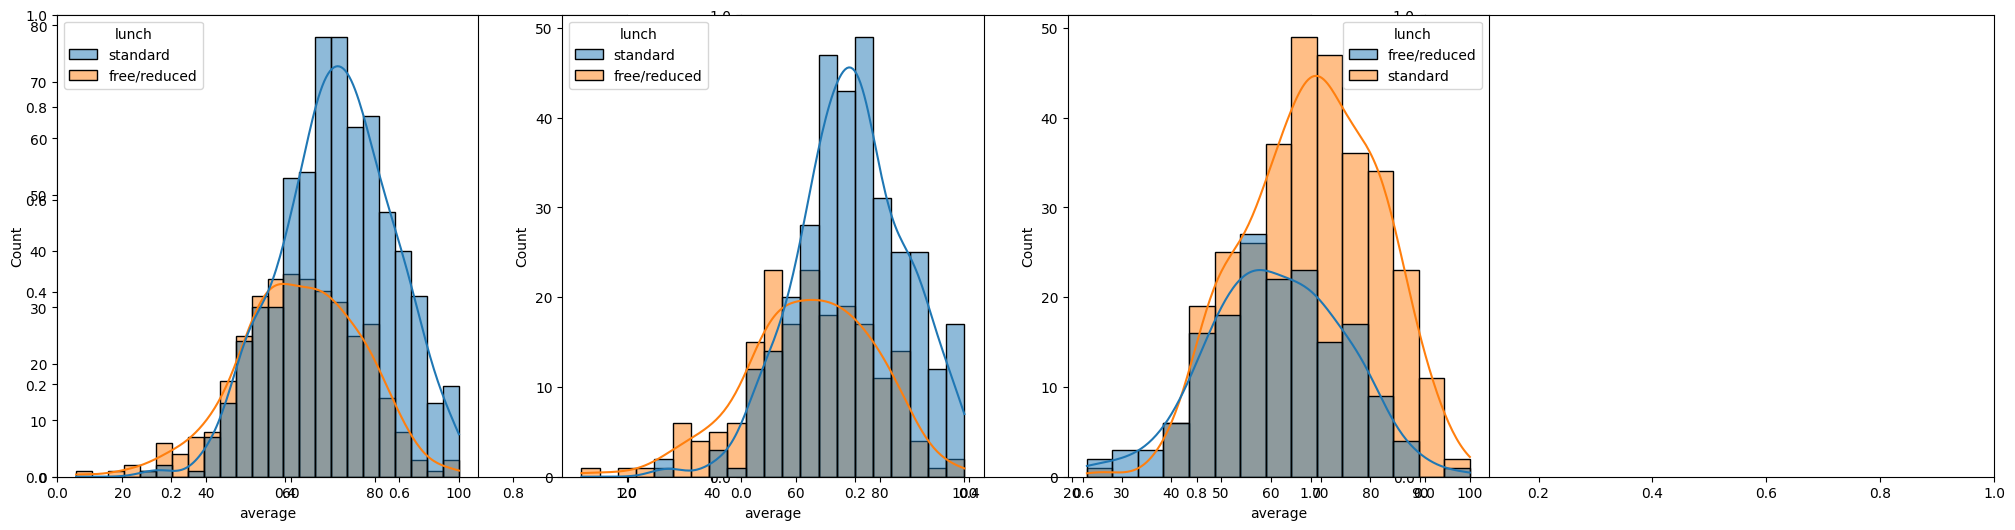

In [23]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(141)
sns.histplot(data=df, x='average', kde=True, hue='lunch')
plt.subplot(142)
sns.histplot(data=df[df.gender=='female'], x='average', kde=True, hue='lunch')
plt.subplot(143)
sns.histplot(data=df[df.gender=='male'], x='average', kde=True, hue='lunch')
plt.show()

### Insights
- Standard lunch helps perform well in exams (be it a male or a female).

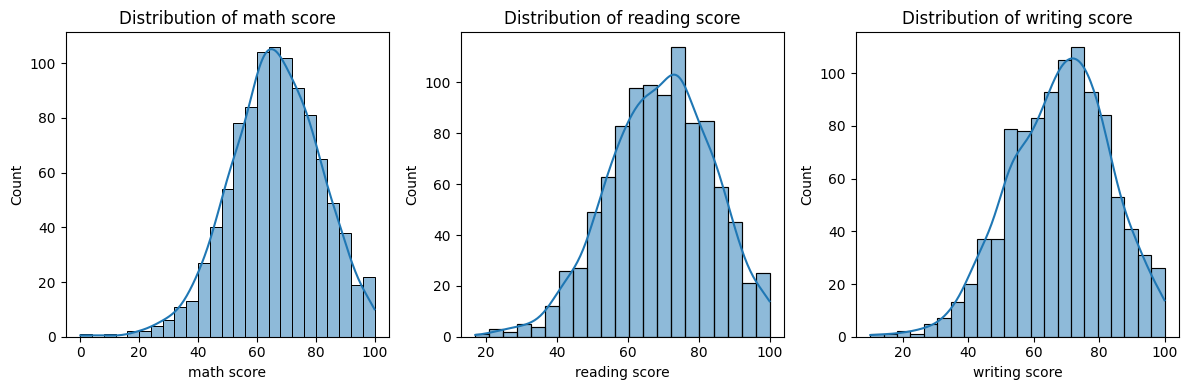

In [24]:
# -----------------------------------------------------
# 1. Distribution of Scores (Histogram)
# -----------------------------------------------------
plt.figure(figsize=(12,4))
for i, col in enumerate(["math score","reading score","writing score"]):
    plt.subplot(1,3,i+1)
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

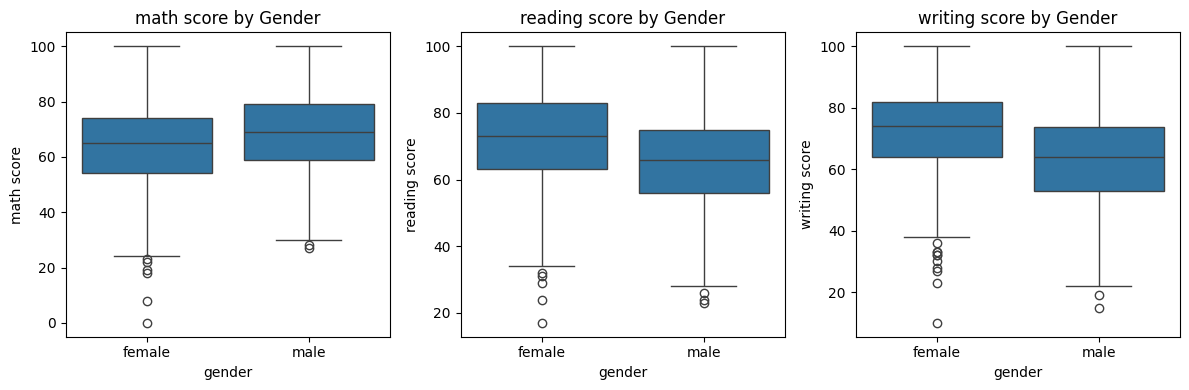

In [25]:
# -----------------------------------------------------
# 2. Boxplots of Scores by Gender
# -----------------------------------------------------
plt.figure(figsize=(12,4))
for i, col in enumerate(["math score","reading score","writing score"]):
    plt.subplot(1,3,i+1)
    sns.boxplot(data=df, x="gender", y=col)
    plt.title(f"{col} by Gender")
plt.tight_layout()
plt.show()

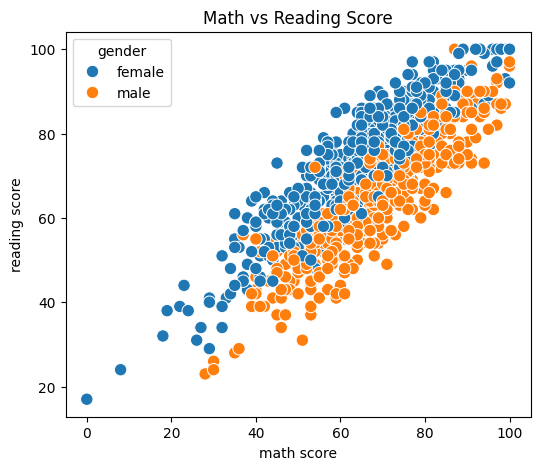

In [26]:
# -----------------------------------------------------
# 3. Scatter Plot – Math vs Reading (Colored by Gender)
# -----------------------------------------------------
plt.figure(figsize=(6,5))
sns.scatterplot(data=df, x="math score", y="reading score", hue="gender", s=80)
plt.title("Math vs Reading Score")
plt.show()

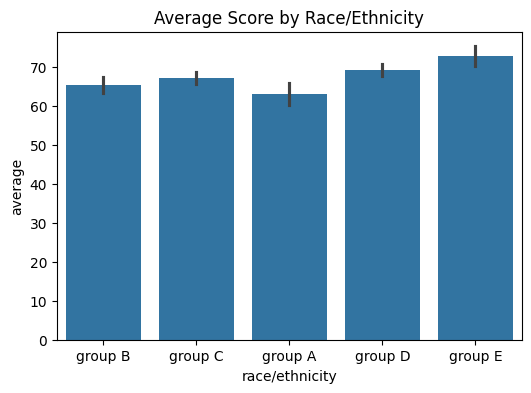

In [27]:
# -----------------------------------------------------
# 4. Average Score by Race/Ethnicity
# -----------------------------------------------------
df["average"] = df[["math score","reading score","writing score"]].mean(axis=1)

plt.figure(figsize=(6,4))
sns.barplot(data=df, x="race/ethnicity", y="average")
plt.title("Average Score by Race/Ethnicity")
plt.show()

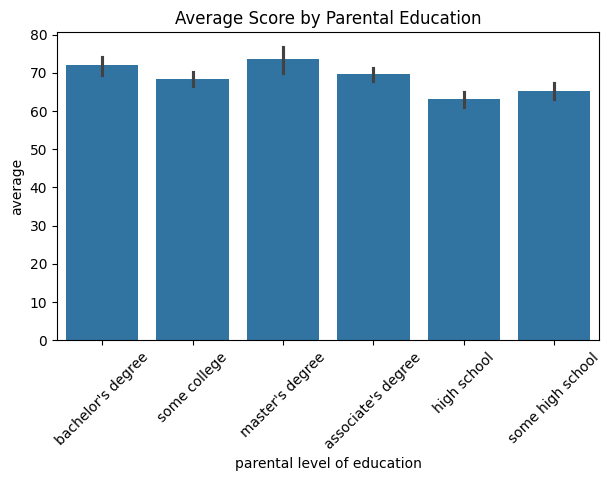

In [28]:
# -----------------------------------------------------
# 5. Parental Education vs Average Score
# -----------------------------------------------------
plt.figure(figsize=(7,4))
sns.barplot(data=df, x="parental level of education", y="average")
plt.title("Average Score by Parental Education")
plt.xticks(rotation=45)
plt.show()

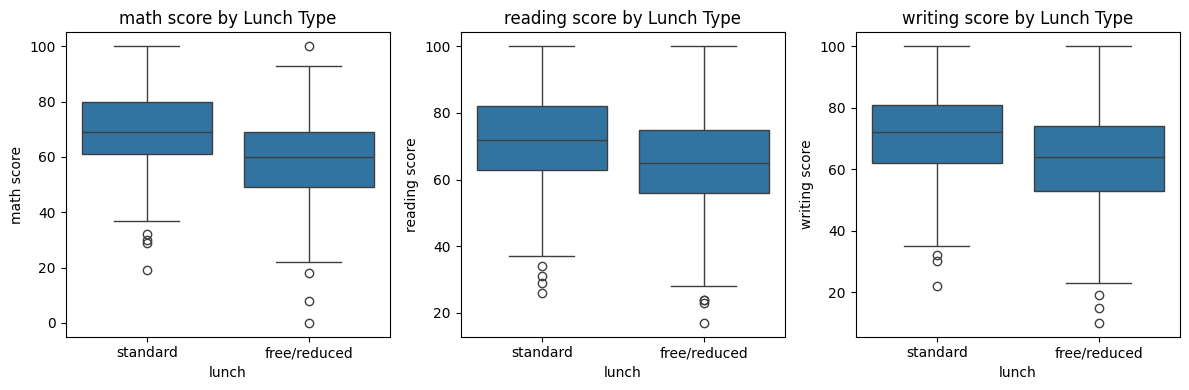

In [32]:
# -----------------------------------------------------
# 6. Lunch Type vs Scores
# -----------------------------------------------------
plt.figure(figsize=(12,4))
for i, col in enumerate(["math score","reading score","writing score"]):
    plt.subplot(1,3,i+1)
    sns.boxplot(data=df, x="lunch", y=col)
    plt.title(f"{col} by Lunch Type")
plt.tight_layout()
plt.show()

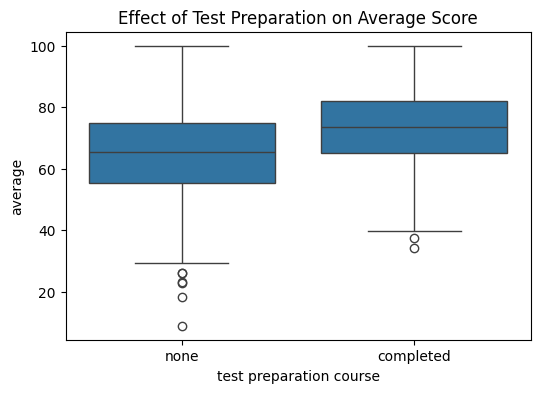

In [34]:
# -----------------------------------------------------
# 7. Test Preparation vs Average Score
# -----------------------------------------------------
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="test preparation course", y="average")
plt.title("Effect of Test Preparation on Average Score")
plt.show()

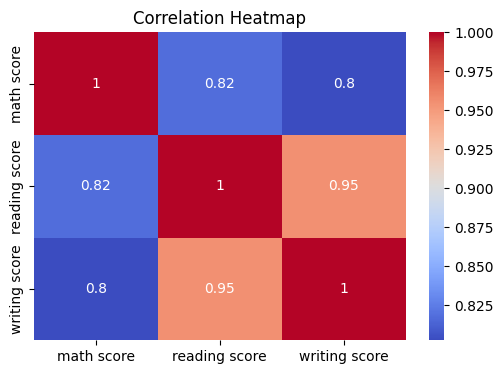

In [36]:
# -----------------------------------------------------
# 8. Heatmap of Score Correlations
# -----------------------------------------------------
plt.figure(figsize=(6,4))
sns.heatmap(df[["math score","reading score","writing score"]].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()